# scRNA-seq Quality Control

Place the input dataset at `data/quality_control_adata.h5ad` before running the notebook.

In [ ]:
# Import analysis packages and configure Scanpy
from pathlib import Path
import numpy as np
import scanpy as sc
import seaborn as sns
from rpy2.robjects import numpy2ri
from rpy2.robjects.conversion import localconverter
from scipy.sparse import csc_matrix
from scipy.stats import median_abs_deviation

# Suppress verbose logging from Scanpy
sc.settings.verbosity = 0

# Set figure parameters for clean, minimal plots
sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False)


In [ ]:
# Load the local AnnData dataset
DATA_PATH = Path("data/quality_control_adata.h5ad")
adata = sc.read_h5ad(DATA_PATH)
adata


AnnData object with n_obs × n_vars = 16934 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

In [ ]:
# Make gene names unique
adata.var_names_make_unique()
adata


AnnData object with n_obs × n_vars = 16934 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

## Cell quality control

In [ ]:
# Annotate mitochondrial, ribosomal, and hemoglobin genes
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))

# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains(r"^HB[ABDEGMQZ]\d*(?!\w)")


In [ ]:
# Calculate cell- and gene-level QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo", "hb"],
    inplace=True,
    percent_top=[20],
    log1p=True,
)

adata


AnnData object with n_obs × n_vars = 16934 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

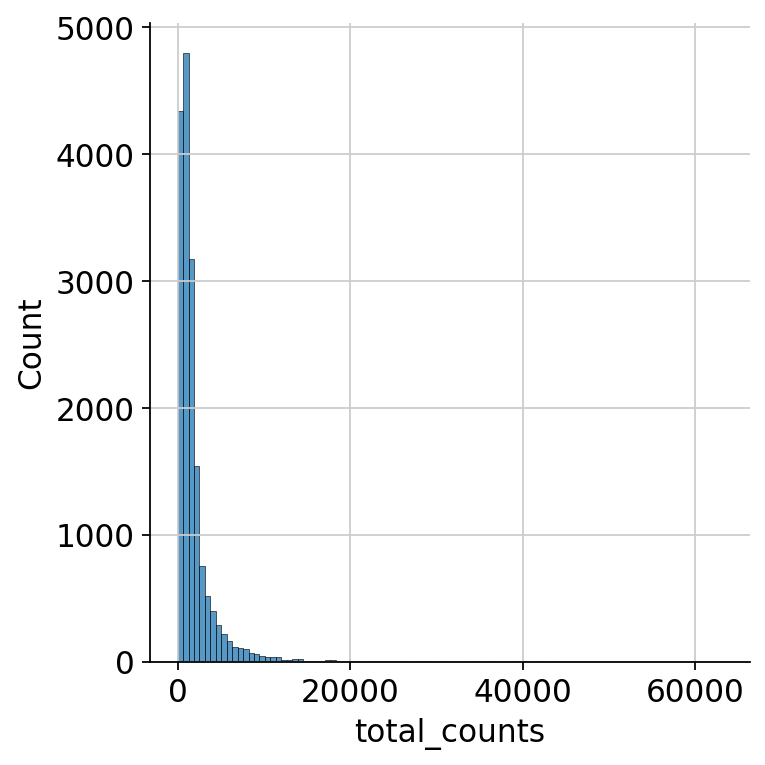

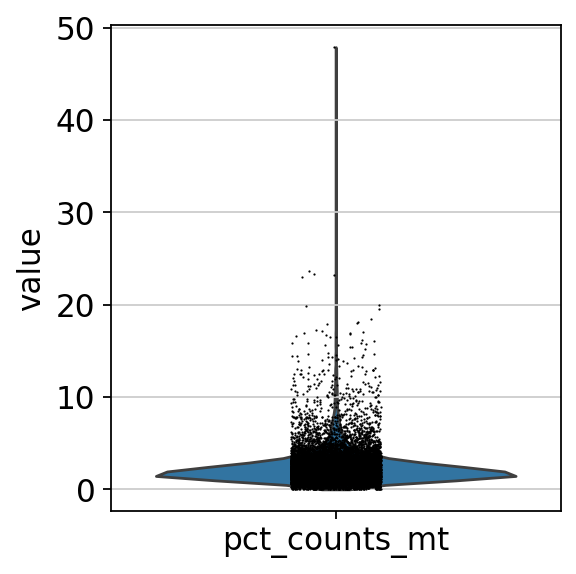

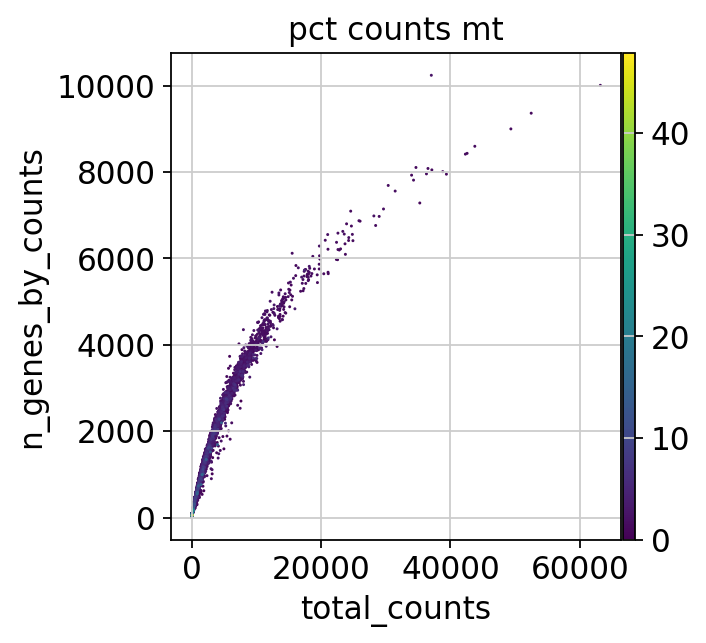

In [ ]:
# Visualize the main QC metrics
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(
    adata,
    "total_counts",
    "n_genes_by_counts",
    color="pct_counts_mt",
)


In [ ]:
# Define a MAD-based outlier detector
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]

    outlier = (
        M < np.median(M) - nmads * median_abs_deviation(M)
    ) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )

    return outlier


In [ ]:
# Flag cells with extreme QC metrics
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)

adata.obs.outlier.value_counts()


outlier
False    16065
True       869
Name: count, dtype: int64

In [ ]:
# Flag cells with high mitochondrial counts
adata.obs["mt_outlier"] = (
    is_outlier(adata, "pct_counts_mt", 3)
    | (adata.obs["pct_counts_mt"] > 8)
)

adata.obs.mt_outlier.value_counts()


mt_outlier
False    15240
True      1694
Name: count, dtype: int64

In [ ]:
# Remove low-quality cells
print(f"Total number of cells: {adata.n_obs}")

adata = adata[
    (~adata.obs.outlier) & (~adata.obs.mt_outlier)
].copy()

print(
    f"Number of cells after filtering of low quality cells: "
    f"{adata.n_obs}"
)


Total number of cells: 16934
Number of cells after filtering of low quality cells: 14814


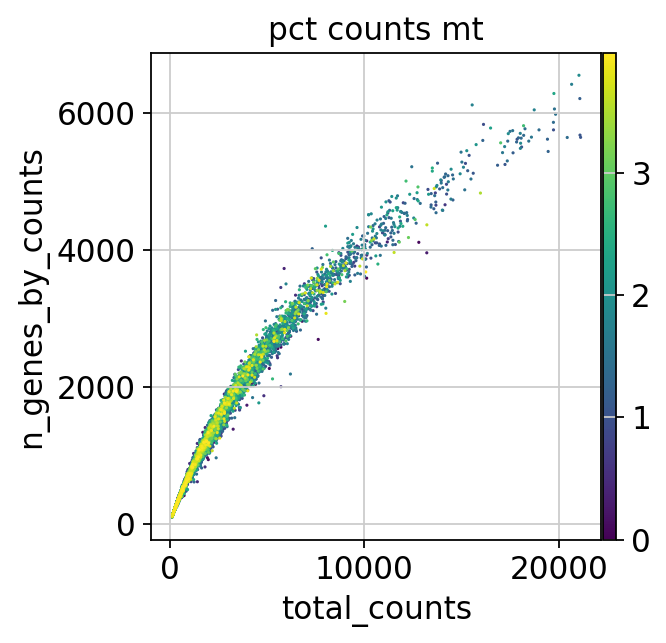

In [ ]:
# Recheck QC metrics after filtering
p1 = sc.pl.scatter(
    adata,
    "total_counts",
    "n_genes_by_counts",
    color="pct_counts_mt",
)


## Ambient RNA correction

In [ ]:
# Import Python-R interface tools for SoupX
import logging

import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

rcb.logger.setLevel(logging.ERROR)


In [ ]:
# Enable R cells in Jupyter
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R
# Load SoupX in R
library(SoupX)


In [ ]:
# Prepare a normalized copy for clustering
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp, target_sum=1e4)
sc.pp.log1p(adata_pp)


In [ ]:
# Build Leiden clusters for SoupX
sc.pp.pca(adata_pp)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(
    adata_pp, key_added="soupx_groups", flavor="igraph", n_iterations=2, directed=False
)

# Preprocess variables for SoupX
adata.obs["soupx_groups"] = adata_pp.obs["soupx_groups"]


In [ ]:
# Remove the temporary clustering object
del adata_pp


In [ ]:
# Prepare the filtered count matrix for SoupX
cells = adata.obs_names
genes = adata.var_names
data = adata.X.T


In [ ]:
# Reload the original dataset for SoupX
adata_raw = sc.read_h5ad(DATA_PATH)
adata_raw.var_names_make_unique()

genes_raw = adata_raw.var_names
cells_raw = adata_raw.obs_names

data_tod = adata_raw.X.T


In [ ]:
# Remove the temporary raw-data object
del adata_raw


In [ ]:
# Convert sparse matrices for transfer to R
data_csc = data.tocsc()
data_tod_csc = data_tod.tocsc()

# Extract sparse components and cast to correct types
x = data_csc.data.astype(np.float64)
i = data_csc.indices.astype(np.int32)
p = data_csc.indptr.astype(np.int32)
dims = np.array(data_csc.shape, dtype=np.int32)

x_tod = data_tod_csc.data.astype(np.float64)
i_tod = data_tod_csc.indices.astype(np.int32)
p_tod = data_tod_csc.indptr.astype(np.int32)
dims_tod = np.array(data_tod_csc.shape, dtype=np.int32)


In [ ]:
# Transfer matrices and metadata from Python to R
with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter):
    ro.globalenv["x"] = x
    ro.globalenv["i"] = i
    ro.globalenv["p"] = p
    ro.globalenv["dims"] = dims

    ro.globalenv["x_tod"] = x_tod
    ro.globalenv["i_tod"] = i_tod
    ro.globalenv["p_tod"] = p_tod
    ro.globalenv["dims_tod"] = dims_tod

    ro.globalenv["genes"] = np.array(genes)
    ro.globalenv["genes_raw"] = np.array(genes_raw)
    ro.globalenv["cells"] = np.array(cells)
    ro.globalenv["cells_raw"] = np.array(cells_raw)
    ro.globalenv["soupx_groups"] = adata.obs["soupx_groups"].to_numpy()


In [ ]:
%%R -o out
# Estimate ambient RNA contamination and correct counts

library(Matrix)

# Manually coerce types to avoid "array" class errors
x <- as.numeric(x)
i <- as.integer(i)
p <- as.integer(p)
dims <- as.integer(dims)

x_tod <- as.numeric(x_tod)
i_tod <- as.integer(i_tod)
p_tod <- as.integer(p_tod)
dims_tod <- as.integer(dims_tod)

# Reconstruct sparse matrices
data <- new(
    "dgCMatrix",
    Dim = dims,
    x = x,
    i = i,
    p = p
)

data_tod <- new(
    "dgCMatrix",
    Dim = dims_tod,
    x = x_tod,
    i = i_tod,
    p = p_tod
)

# Assign row and column names
rownames(data) <- genes
colnames(data) <- cells
rownames(data_tod) <- genes_raw
colnames(data_tod) <- cells_raw

# SoupX pipeline
sc = SoupChannel(data_tod, data, calcSoupProfile = TRUE)
sc = setClusters(sc, soupx_groups)
sc = autoEstCont(sc, doPlot = FALSE)
out = adjustCounts(sc, roundToInt = TRUE)


In [ ]:
# Store SoupX-corrected counts in AnnData
with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter):
    out_py = ro.conversion.rpy2py(ro.globalenv["out"])

x = np.array(out_py.slots["x"])
i = np.array(out_py.slots["i"])
p = np.array(out_py.slots["p"])
shape = tuple(out_py.slots["Dim"])

out_matrix = csc_matrix((x, i, p), shape=shape)
adata.layers["counts"] = adata.X.copy()
adata.layers["soupX_counts"] = out_matrix.T
adata.X = adata.layers["soupX_counts"]


In [ ]:
# Remove genes detected in fewer than 20 cells
print(f"Total number of genes: {adata.n_vars}")

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(adata, min_cells=20)

print(f"Number of genes after cell filter: {adata.n_vars}")


Total number of genes: 36601
Number of genes after cell filter: 20121


## Doublet detection

In [ ]:
%%R
# Load R packages for doublet detection
library(Seurat)
library(scater)
library(scDblFinder)
library(SingleCellExperiment)
library(BiocParallel)


In [ ]:
# Transfer the count matrix to R
data_mat = adata.X.T.tocsc()

x = data_mat.data.astype(np.float64)
i = data_mat.indices.astype(np.int32)
p = data_mat.indptr.astype(np.int32)
dims = np.array(data_mat.shape, dtype=np.int32)

with localconverter(ro.default_converter + numpy2ri.converter):
    ro.globalenv["x"] = x
    ro.globalenv["i"] = i
    ro.globalenv["p"] = p
    ro.globalenv["dims"] = dims


In [ ]:
%%R -o doublet_score -o doublet_class
# Detect doublets with scDblFinder

x <- as.numeric(x)
i <- as.integer(i)
p <- as.integer(p)
dims <- as.integer(dims)

data_mat <- new(
    "dgCMatrix",
    Dim = dims,
    x = x,
    i = i,
    p = p
)

set.seed(123)

sce <- scDblFinder(
    SingleCellExperiment(
        list(counts = data_mat)
    )
)

doublet_score <- sce$scDblFinder.score
doublet_class <- sce$scDblFinder.class


In [ ]:
# Store doublet scores and labels in AnnData
adata.obs["scDblFinder_score"] = doublet_score
adata.obs["scDblFinder_class"] = doublet_class
adata.obs.scDblFinder_class.value_counts()


scDblFinder_class
singlet    12416
doublet     2398
Name: count, dtype: int64

In [ ]:
# Save the quality-controlled AnnData object
OUTPUT_PATH = Path("results/s4d8_quality_control.h5ad")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(OUTPUT_PATH)
